In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from spectral_cube import SpectralCube
from glob import glob
from astropy import units as u
from astropy.visualization import simple_norm
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from regions import RectangleSkyRegion
from astropy.nddata import Cutout2D

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [2]:
max_CS = fits.open('/orange/adamginsburg/ACES/mosaics/cubes/moments/CS21_CubeMosaic_max.fits')
cs_cube = SpectralCube.read('/orange/adamginsburg/ACES/mosaics/cubes/CS21_CubeMosaic.fits')

In [3]:
point_3D = {
    'coord': SkyCoord(359.6914751557, -0.0698519008, frame='galactic', unit=(u.deg, u.deg)),
    'vel': 50.0*u.km/u.s,
}

In [4]:
(360*u.deg - point_3D['coord'].galactic.l.to(u.deg)).to(u.deg).value

np.float64(0.3085248442999955)

In [5]:
# -0.05 deg - 0.35 deg
# -0.65 deg - -0.25 deg
# -0.35 deg - 0.05 deg
center = -(0.35 + 0.05)/2 
center = SkyCoord(center, 0, frame='galactic', unit=u.deg)
width = (0.35+0.05)*u.deg
height = 0.7*u.deg
reg_cut = RectangleSkyRegion(center=center, width=width, height=height)
#subcube = cs_cube.subcube_from_regions([reg_cut])
cutout = Cutout2D(max_CS[0].data, position=center, size=(height, width), wcs=WCS(max_CS[0].header))

In [6]:
pvpath = '/orange/adamginsburg/ACES/broadline_sources/EVFs/images/CS21/'
pv_l = f'{pvpath}/CS21_pv_l-0.307_mean.fits'
pv_b = f'{pvpath}/CS21_pv_b-0.062_mean.fits'
pv_l_cube = fits.open(pv_l)
pv_l_head = pv_l_cube[0].header
pv_l_data = pv_l_cube[0].data
pv_b_cube = fits.open(pv_b)
pv_b_head = pv_b_cube[0].header
pv_b_data = pv_b_cube[0].data

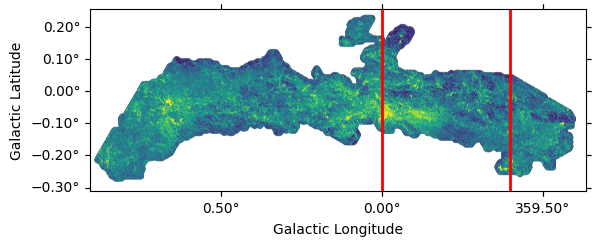

In [7]:
ax = plt.subplot(projection=WCS(max_CS[0].header))
ax.imshow(max_CS[0].data, origin='lower', norm=simple_norm(max_CS[0].data, 'sqrt', percent=99.5))
coord_hvcc = SkyCoord(1.28, 0.06, frame='galactic', unit=(u.deg, u.deg))
#ax.scatter(coord_hvcc.galactic.l, coord_hvcc.galactic.b, color='red', s=100, transform=ax.get_transform('world'), marker='x')
reg_cut.to_pixel(WCS(max_CS[0].header)).plot(ax=ax, facecolor='none', edgecolor='red', lw=2)
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')
ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Galactic Latitude')

<CoordinatesMap with 2 world coordinates:

  index            aliases              type    unit wrap format_unit visible
  ----- ----------------------------- -------- ----- ---- ----------- -------
      0 spect.dopplerveloc.radio vrad   scalar m / s None      km / s     yes
      1         pos.galactic.lat glat latitude   deg None         deg     yes

>


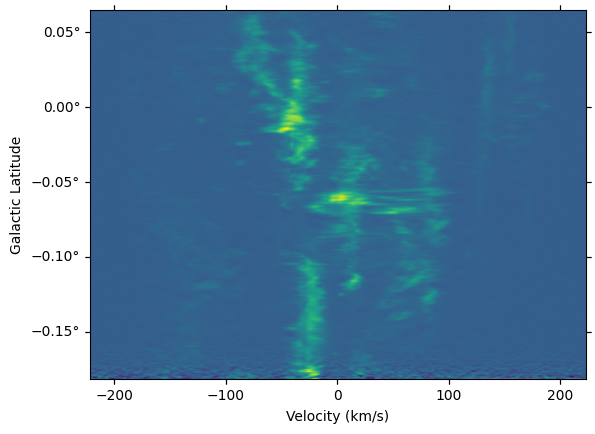

In [8]:
flipped_wcs = WCS(pv_l_head).sub([2,1])
ax = plt.subplot(projection=flipped_wcs)
ax.imshow(pv_l_data.T, aspect='auto')
ax.coords[0].set_format_unit(u.km/u.s)
ax.coords[1].set_major_formatter('d.dd')
ax.set_ylabel('Galactic Latitude')
ax.set_xlabel('Velocity (km/s)')
#ax.coords[0].set_ticklabel_position('lr')
#ax.coords[0].set_axislabel_position('lr')
#ax.coords[0].set_ticks_position('lr')
#ax.coords[1].set_ticklabel_position('bt')
#ax.coords[1].set_axislabel_position('bt')
#ax.coords[1].set_ticks_position('bt')
print(ax.coords)

<CoordinatesMap with 2 world coordinates:

  index            aliases               type   ...    wrap   format_unit visible
  ----- ----------------------------- --------- ... --------- ----------- -------
      0         pos.galactic.lon glon longitude ... 360.0 deg         deg     yes
      1 spect.dopplerveloc.radio vrad    scalar ...      None      km / s     yes

>


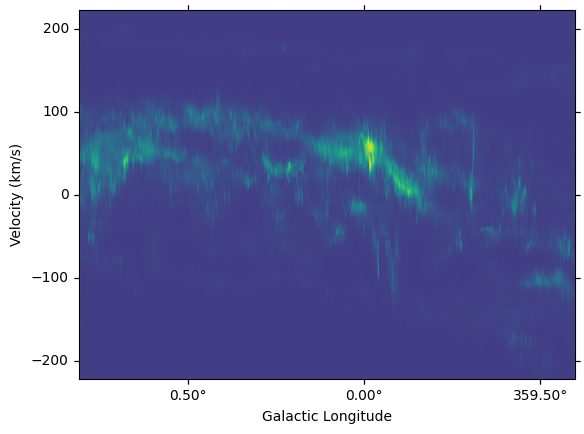

In [9]:
ax = plt.subplot(projection=WCS(pv_b_head))
ax.imshow(pv_b_data, aspect='auto')
ax.coords[1].set_format_unit(u.km/u.s)
ax.coords[0].set_major_formatter('d.dd')
ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Velocity (km/s)')
#ax.coords[0].set_ticklabel_position('lr')
#ax.coords[0].set_axislabel_position('lr')
#ax.coords[0].set_ticks_position('lr')
#ax.coords[1].set_ticklabel_position('bt')
#ax.coords[1].set_axislabel_position('bt')
#ax.coords[1].set_ticks_position('bt')
print(ax.coords)


In [10]:
cs_norm = simple_norm(max_CS[0].data, 'sqrt', percent=99.5)

In [11]:
# Latitude extrema
B_MIN = -0.27 * u.deg
B_MAX = 0.22 * u.deg

# Longitude extrema
L_MIN = -0.59 * u.deg
L_MAX = 0.88 * u.deg

latitude = -0.062 * u.deg
longitude = -0.307 * u.deg

reg_b = RectangleSkyRegion(center=SkyCoord((L_MIN + L_MAX) / 2., latitude, frame='galactic'), width=1.5 * u.deg, height=1 * u.arcmin)
reg_l = RectangleSkyRegion(center=SkyCoord(longitude, (B_MIN + B_MAX) / 2., frame='galactic'), width=1 * u.arcmin, height=0.5 * u.deg)

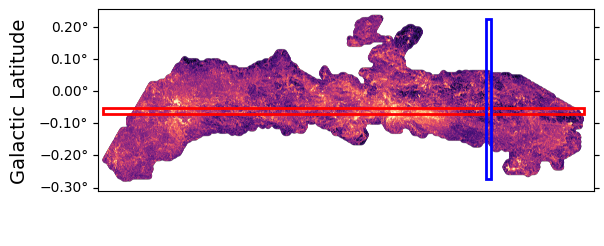

In [12]:
ax = plt.subplot(projection=WCS(max_CS[0].header))
ax.imshow(max_CS[0].data, origin='lower', norm=cs_norm, cmap='magma')
ax.coords[0].set_major_formatter('d')
ax.coords[1].set_major_formatter('d.dd')
#ax.set_xlabel('Galactic Longitude')
ax.set_xlabel(' ')
ax.set_ylabel('Galactic Latitude', fontsize=14)
#ax.get_xaxis().set_visible(False)
ax.xaxis.label.set_color('white')
ax.tick_params(axis='x', colors='white')
reg_b.to_pixel(WCS(max_CS[0].header)).plot(ax=ax, facecolor='none', edgecolor='red', lw=2)
reg_l.to_pixel(WCS(max_CS[0].header)).plot(ax=ax, facecolor='none', edgecolor='blue', lw=2)

In [13]:
from astropy.wcs.utils import proj_plane_pixel_scales
SkyCoord((L_MIN + L_MAX) / 2., latitude, frame='galactic').to_pixel(WCS(max_CS[0].header))

(array(5502.41066197), array(1800.19982537))

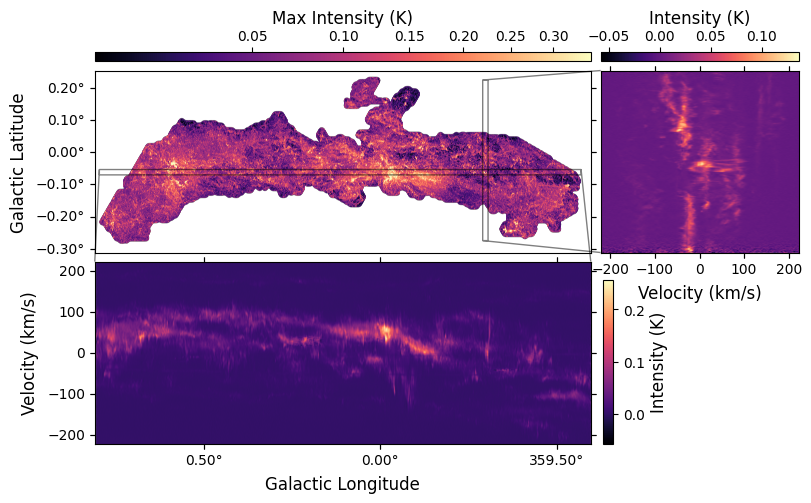

In [28]:
ax = plt.subplot(projection=WCS(max_CS[0].header))
im = ax.imshow(max_CS[0].data, origin='lower', norm=cs_norm, cmap='magma')
ax.coords[0].set_major_formatter('d')
ax.coords[1].set_major_formatter('d.dd')
#ax.set_xlabel('Galactic Longitude')
ax.set_xlabel(' ')
ax.set_ylabel('Galactic Latitude', fontsize=12)
#ax.get_xaxis().set_visible(False)
ax.xaxis.label.set_color('white')
ax.tick_params(axis='x', colors='white')
pixelscale = u.pixel_scale(proj_plane_pixel_scales(WCS(max_CS[0].header))[0]*u.deg/u.pix)
cax = ax.inset_axes([0, 1.05, 1, 0.05])
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('Max Intensity (K)', fontsize=12)
# put colorbar label above the colorbar
cbar.ax.xaxis.set_label_position('top')
# put colorbar axis ticks on top
cbar.ax.xaxis.set_ticks_position('top')

ax_ins2 = ax.inset_axes([0, -1.05, 1, 1], projection=WCS(pv_b_head))
ax_ins2.coords[0].set_major_formatter('d.dd')
im2 = ax_ins2.imshow(pv_b_data, aspect='auto', cmap='magma')
ax_ins2.coords[1].set_format_unit(u.km/u.s)
ax_ins2.set_xlabel('Galactic Longitude', fontsize=12)
ax_ins2.set_ylabel('Velocity (km/s)', fontsize=12)
pos1 = SkyCoord((L_MIN + L_MAX) / 2., latitude, frame='galactic').to_pixel(WCS(max_CS[0].header))
dx = (1.5*u.deg).to(u.pix, equivalencies=pixelscale).value
dy = (1*u.arcmin).to(u.pix, equivalencies=pixelscale).value
ax_indic2 = ax.indicate_inset(inset_ax=ax_ins2, edgecolor='k', linewidth=1, bounds=[pos1[0]-dx/2, pos1[1]-dy/2, dx, dy])
cax2 = ax_ins2.inset_axes([1.025, 0, 0.02, 0.9])
cbar2 = plt.colorbar(im2, cax=cax2, orientation='vertical')
cbar2.set_label('Intensity (K)', fontsize=12)
ax_indic2.connectors[0].set(visible = False)
ax_indic2.connectors[1].set(visible = True)
ax_indic2.connectors[2].set(visible = False)
ax_indic2.connectors[3].set(visible = True)

ax_ins1 = ax.inset_axes([1.02, 0, 0.4, 1], projection=flipped_wcs)
im1 = ax_ins1.imshow(pv_l_data.T, aspect='auto', cmap='magma')
ax_ins1.coords[1].set_major_formatter('d')
ax_ins1.coords[0].set_format_unit(u.km/u.s)
ax_ins1.set_xlabel('Velocity (km/s)', fontsize=12)
ax_ins1.set_ylabel(' ')
ax_ins1.yaxis.label.set_color('white')
ax_ins1.tick_params(axis='y', colors='white')
pos2 = SkyCoord(longitude, (B_MIN + B_MAX) / 2., unit=u.deg, frame='galactic').to_pixel(WCS(max_CS[0].header))
dx = (1*u.arcmin).to(u.pix, equivalencies=pixelscale).value
dy = (0.5*u.deg).to(u.pix, equivalencies=pixelscale).value
ax_indic1 = ax.indicate_inset(inset_ax=ax_ins1, edgecolor='k', linewidth=1, bounds=[pos2[0]-dx/2, pos2[1]-dy/2, dx, dy])
cax1 = ax_ins1.inset_axes([0, 1.05, 1, 0.05])
cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.set_label('Intensity (K)', fontsize=12)
# put colorbar label above the colorbar
cbar1.ax.xaxis.set_label_position('top')
# put colorbar axis ticks on top
cbar1.ax.xaxis.set_ticks_position('top')
ax_indic1.connectors[0].set(visible = True)
ax_indic1.connectors[1].set(visible = True)
ax_indic1.connectors[2].set(visible = False)
ax_indic1.connectors[3].set(visible = False)

#plt.savefig('./by_eye_identification.svg', bbox_inches='tight', dpi=300)
plt.savefig('./by_eye_identification.pdf', bbox_inches='tight', dpi=300)

In [ ]:
# might be difficult to see the EVF
# make the figure taller

In [12]:
fn_pvb = '/blue/adamginsburg/savannahgramze/ACES_EVF/aces_evf/CS21_pv_b-0.062_mean.fits'
fn_pvl = '/blue/adamginsburg/savannahgramze/ACES_EVF/aces_evf/CS21_pv_l-0.307_mean.fits'

pvb_ = fits.open(fn_pvb)
pvl_ = fits.open(fn_pvl)

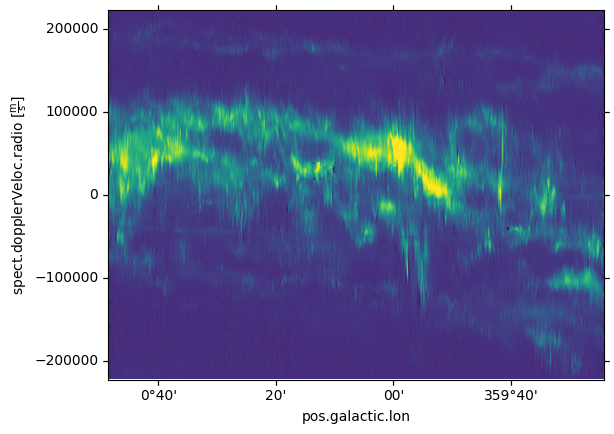

In [5]:
ax = plt.subplot(projection=WCS(pvb_[0].header))
ax.imshow(pvb_[0].data, origin='lower', norm=simple_norm(pvb_[0].data, 'sqrt', percent=99.5), aspect='auto')

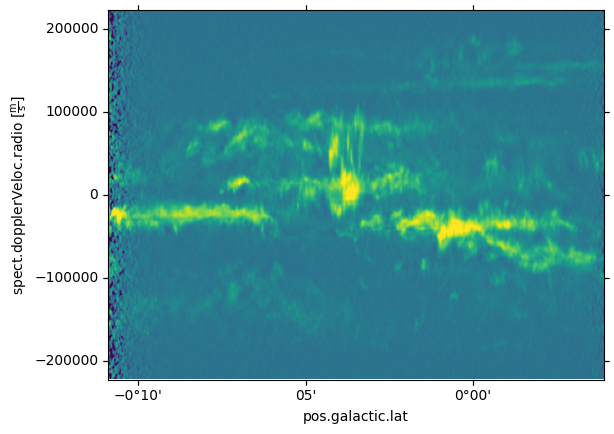

In [8]:
ax = plt.subplot(projection=WCS(pvl_[0].header))
ax.imshow(pvl_[0].data, origin='lower', norm=simple_norm(pvl_[0].data, 'sqrt', percent=99.5), aspect='auto')

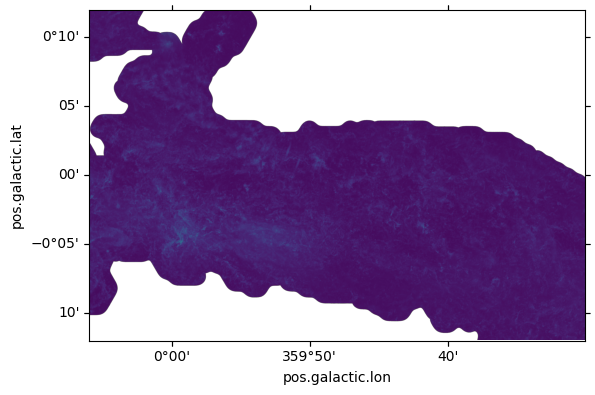

In [25]:
ax = plt.subplot(projection=cutout.wcs)
ax.imshow(cutout.data)

In [13]:
flip_wcs = WCS(pvl_[0].header).sub([2,1])

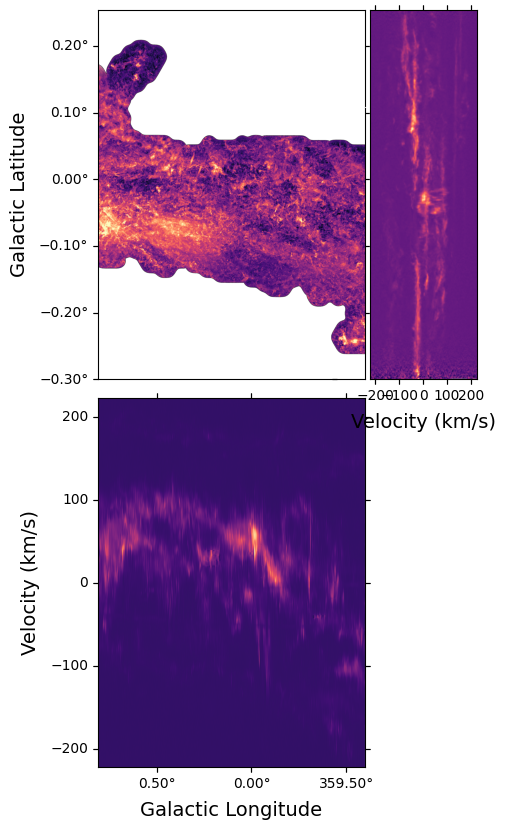

In [ ]:
ax = plt.subplot(projection=cutout.wcs)
ax.imshow(cutout.data, origin='lower', norm=simple_norm(cutout.data, 'sqrt', percent=99.5), cmap='magma')
ax.coords[0].set_major_formatter('d')
ax.coords[1].set_major_formatter('d.dd')
#ax.set_xlabel('Galactic Longitude')
ax.set_xlabel(' ')
ax.set_ylabel('Galactic Latitude', fontsize=14)
#ax.get_xaxis().set_visible(False)
ax.xaxis.label.set_color('white')
ax.tick_params(axis='x', colors='white')

ax_ins2 = ax.inset_axes([0, -1.05, 1, 1], projection=WCS(pv_b_head))
ax_ins2.coords[0].set_major_formatter('d.dd')
ax_ins2.imshow(pv_b_data, aspect='auto', cmap='magma')
ax_ins2.coords[1].set_format_unit(u.km/u.s)
ax_ins2.set_xlabel('Galactic Longitude', fontsize=14)
ax_ins2.set_ylabel('Velocity (km/s)', fontsize=14)
ax_ins2.set_xlim()

ax_ins1 = ax.inset_axes([1.02, 0, 0.4, 1], projection=flipped_wcs)
ax_ins1.imshow(pv_l_data.T, aspect='auto', cmap='magma')
ax_ins1.coords[1].set_major_formatter('d')
ax_ins1.coords[0].set_format_unit(u.km/u.s)
ax_ins1.set_xlabel('Velocity (km/s)', fontsize=14)
ax_ins1.set_ylabel(' ')
#ax_ins1.set_yticklabels([])
#ax_ins1.spines['bottom'].set_color('red')
#ax_ins1.spines['top'].set_color('red')
ax_ins1.yaxis.label.set_color('white')
ax_ins1.tick_params(axis='y', colors='white')

#plt.savefig('./by_eye_identification.pdf', bbox_inches='tight', dpi=300)

In [10]:
lon_b_min + lon_b_max

0.21219740611065996